# Customer Churn Prediction — Exploratory Data Analysis (EDA)

> **Objective:** Perform a structured Exploratory Data Analysis on telecom customer churn data to uncover behavioural patterns, quantify churn risk factors, and prepare actionable insights for a Machine Learning pipeline.

---

## 📋 Project Workflow

| # | Section | Description |
|---|---------|-------------|
| 1 | **Setup & Initial Exploration** | Load data, inspect structure, distributions, and outliers |
| 2 | **Categorical Features vs. Churn** | Visualise how each categorical variable relates to churn |
| 3 | **EDA Insights & Strategic Action Plan** | Business-level findings ranked by priority |
| 4 | **Feature Engineering & Encoding** | Encode variables and build a correlation analysis |
| 5 | **Correlation Analysis — Golden Insights** | Translate correlation results into ML-ready decisions |

---
# Section 1 — Setup & Initial Data Exploration

## 1.1 — Library Imports & Global Plot Settings

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import math
import warnings

# ── Global settings ───────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1.2 — Load Dataset & Structural Overview

In [29]:
df = pd.read_csv('cleaned_data.csv')

print('── First 5 Rows ──────────────────────────────────────────────────────────')
display(df.head())

print('\n── Data Types & Non-Null Counts ──────────────────────────────────────────')
df.info()

print('\n── Statistical Summary (Numeric Columns) ─────────────────────────────────')
display(df.describe())

print('\n── Target Variable: Churn Distribution ───────────────────────────────────')
print(df['Churn'].value_counts())

── First 5 Rows ──────────────────────────────────────────────────────────


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



── Data Types & Non-Null Counts ──────────────────────────────────────────
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBill

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000



── Target Variable: Churn Distribution ───────────────────────────────────
Churn
No     5174
Yes    1869
Name: count, dtype: int64


## 1.3 — Target Variable: Churn Distribution

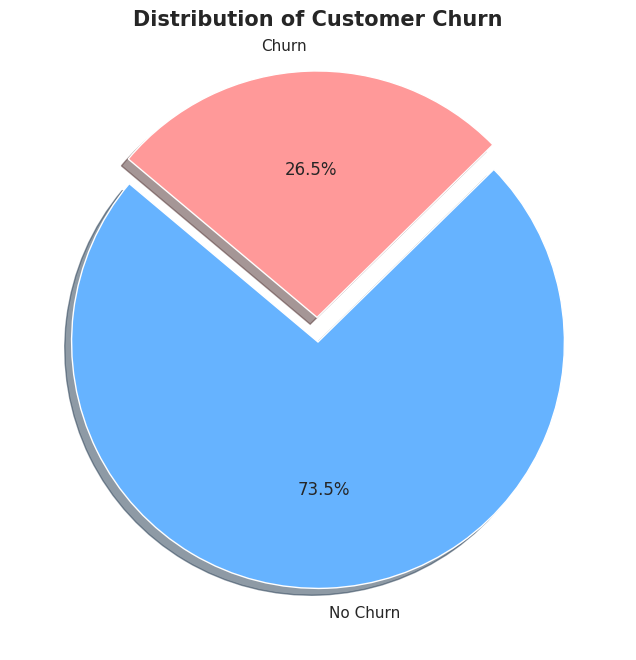

── Churn Counts ──────────────────────────────────────────────────────────
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [30]:
churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(
    churn_counts,
    labels=['No Churn', 'Churn'],
    autopct='%1.1f%%',
    startangle=140,
    colors=['#66b3ff', '#ff9999'],
    explode=(0, 0.1),
    shadow=True
)
plt.title('Distribution of Customer Churn', fontsize=15, fontweight='bold')
plt.show()

print('── Churn Counts ──────────────────────────────────────────────────────────')
print(churn_counts)

### 📌 Key Insights — Class Imbalance

> - The dataset is **imbalanced**: approximately **73% of customers did not churn**, while only ~27% did.
> - This imbalance **must be addressed** during model training to prevent the classifier from simply predicting the majority class.
> - Recommended strategies: **SMOTE** (oversampling), **class_weight='balanced'** in sklearn models, or **stratified k-fold** cross-validation.

## 1.4 — Demographic Distributions (Gender, Partner, Dependents)

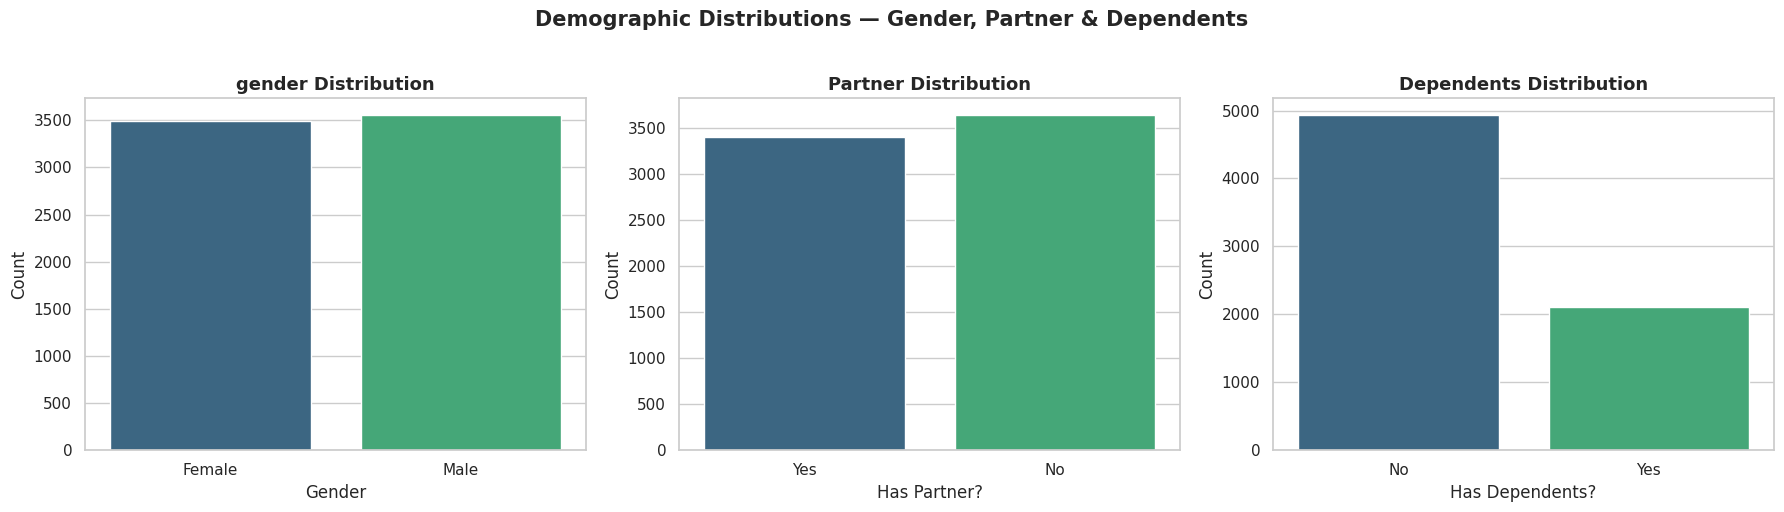

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

demographic_vars = [
    ('gender',     'Gender'),
    ('Partner',    'Has Partner?'),
    ('Dependents', 'Has Dependents?')
]

for ax, (col, xlabel) in zip(axes, demographic_vars):
    sns.countplot(x=col, data=df, ax=ax, palette='viridis')
    ax.set_title(f'{col} Distribution', fontsize=13, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')

plt.suptitle('Demographic Distributions — Gender, Partner & Dependents',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 1.4.1 — Senior Citizen Distribution

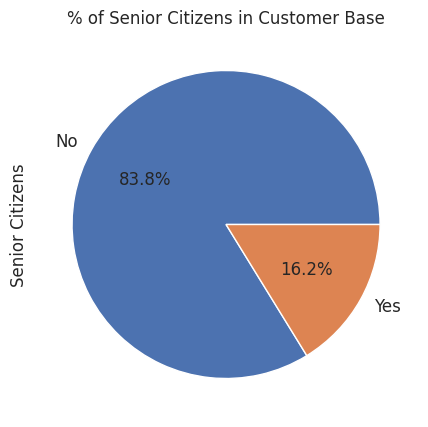

In [32]:
ax = (df['SeniorCitizen'].value_counts() * 100.0 / len(df)).plot.pie(
    autopct='%.1f%%',
    labels=['No', 'Yes'],
    figsize=(5, 5),
    fontsize=12
)
ax.set_ylabel('Senior Citizens', fontsize=12)
ax.set_title('% of Senior Citizens in Customer Base', fontsize=12)
plt.show()

### 1.4.2 — Dependents Distribution by Partner Status

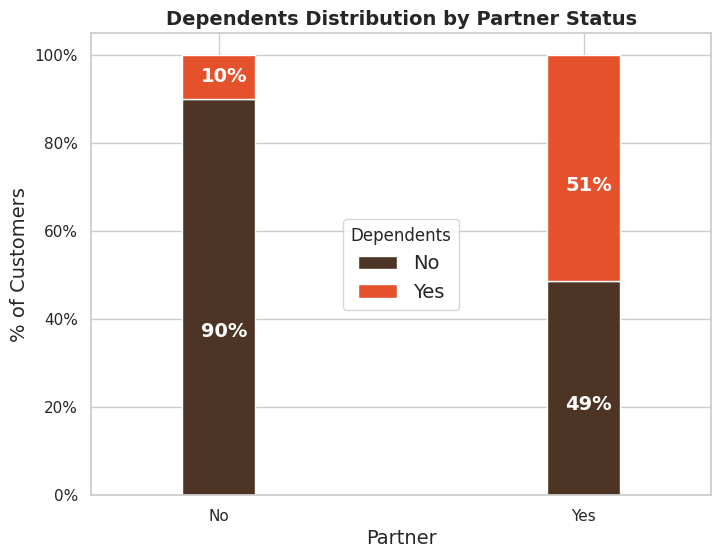

In [33]:
colors = ['#4D3425', '#E4512B']
partner_dependents = df.groupby(['Partner', 'Dependents']).size().unstack()

ax = (partner_dependents.T * 100.0 / partner_dependents.T.sum()).T.plot(
    kind='bar',
    width=0.2,
    stacked=True,
    rot=0,
    figsize=(8, 6),
    color=colors
)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(loc='center', prop={'size': 14}, title='Dependents', fontsize=14)
ax.set_ylabel('% of Customers', size=14)
ax.set_title('Dependents Distribution by Partner Status', size=14, fontweight='bold')
ax.xaxis.label.set_size(14)

# Annotate bars with percentage values
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.annotate(
        '{:.0f}%'.format(height),
        (p.get_x() + .25 * width, p.get_y() + .4 * height),
        color='white', weight='bold', size=14
    )
plt.show()

### 📌 Key Insights — Demographics

> - **Gender** is nearly perfectly balanced — it is unlikely to be a strong churn predictor.
> - Customers **without a partner** and **without dependents** represent the highest churn-risk demographic. Single, independent customers have fewer ties that encourage loyalty.
> - **Senior citizens** represent only ~16% of the customer base, yet they carry a disproportionately higher churn rate — dedicated retention programmes (discounts, simplified support channels) should be considered for this segment.

## 1.5 — Numerical Variable Distributions

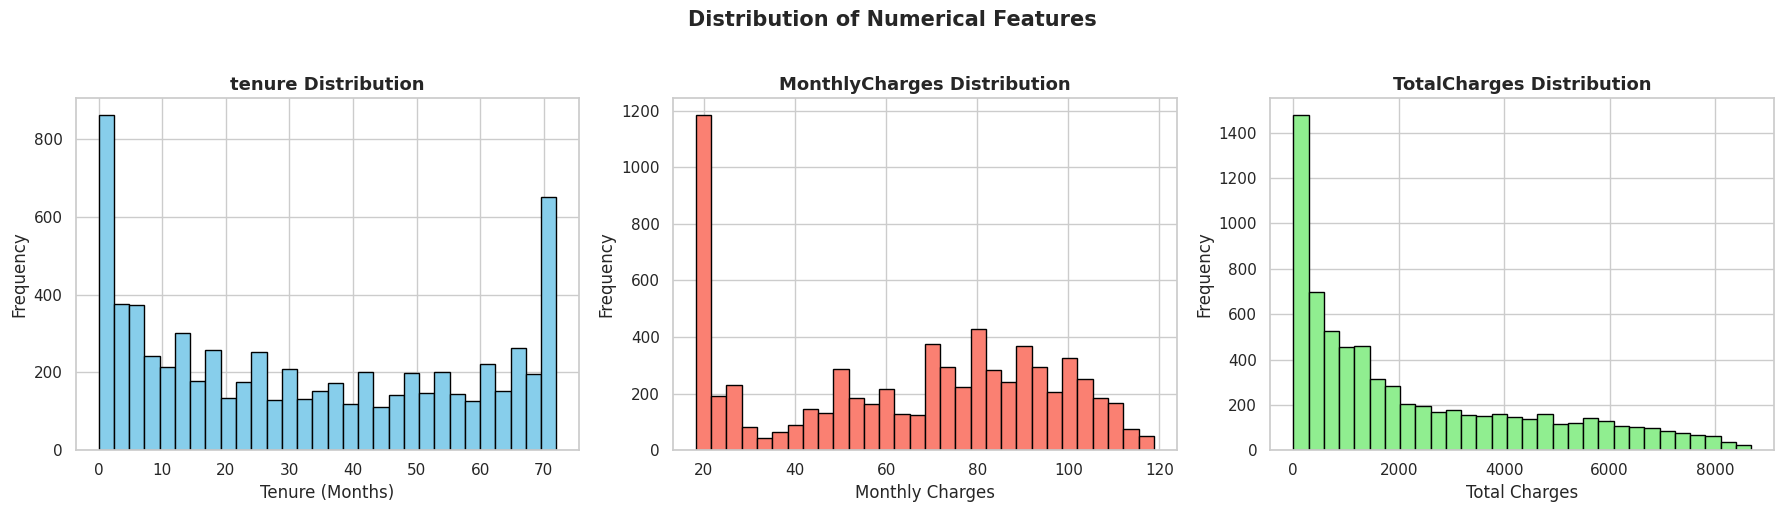

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

hist_config = [
    ('tenure',         'Tenure (Months)',  'skyblue'),
    ('MonthlyCharges', 'Monthly Charges',  'salmon'),
    ('TotalCharges',   'Total Charges',    'lightgreen'),
]

for ax, (col, xlabel, color) in zip(axes, hist_config):
    df[col].hist(bins=30, color=color, edgecolor='black', ax=ax)
    ax.set_title(f'{col} Distribution', fontsize=13, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Frequency')

plt.suptitle('Distribution of Numerical Features', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 1.6 — Churn Distribution Across Numerical Features (KDE Plots)

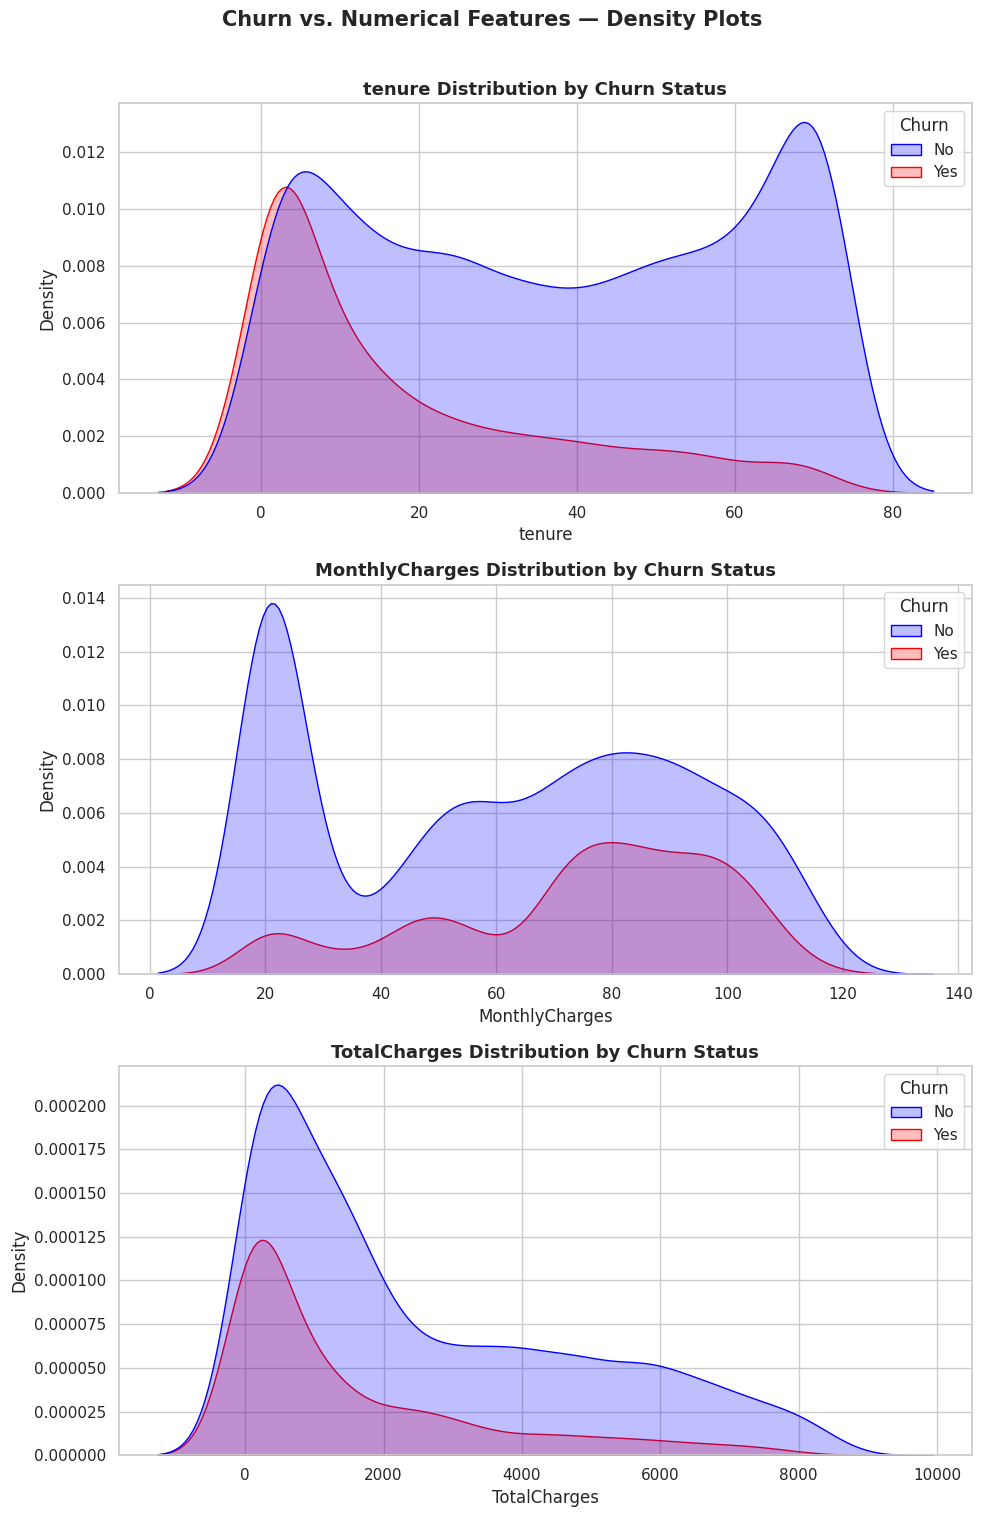

In [35]:
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

kde_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

for ax, col in zip(axes, kde_features):
    sns.kdeplot(
        data=df, x=col, hue='Churn', fill=True,
        palette={'Yes': 'red', 'No': 'blue'}, ax=ax
    )
    ax.set_title(f'{col} Distribution by Churn Status', fontsize=13, fontweight='bold')

plt.suptitle('Churn vs. Numerical Features — Density Plots',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 1.7 — Tenure vs. Churn & Monthly vs. Total Charges

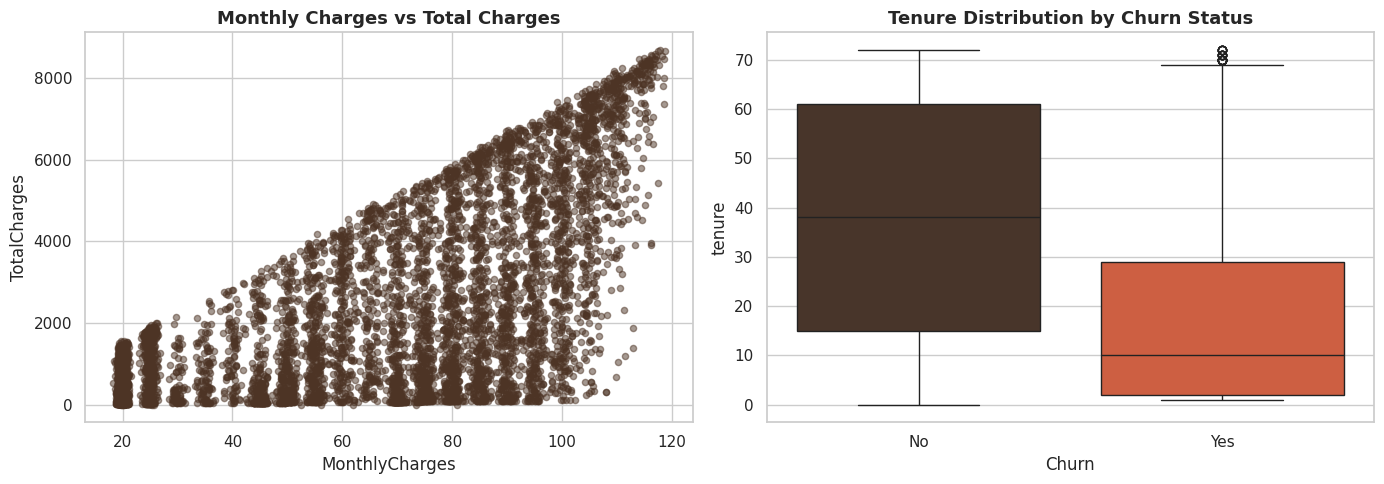

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter Plot: Monthly Charges vs Total Charges
df.plot.scatter(
    x='MonthlyCharges', y='TotalCharges',
    ax=axes[0], color='#4D3425', alpha=0.5
)
axes[0].set_title('Monthly Charges vs Total Charges', fontsize=13, fontweight='bold')

# Boxplot: Tenure by Churn Status
sns.boxplot(
    x=df['Churn'], y=df['tenure'],
    ax=axes[1], palette={'Yes': '#E4512B', 'No': '#4D3425'}
)
axes[1].set_title('Tenure Distribution by Churn Status', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### 📌 Key Insights — Numerical Features

> - **Tenure:** Churned customers have a strongly **left-skewed distribution** — most leave within the first few months. Customers who stay longer are far less likely to churn. This makes tenure one of the most powerful predictors.
> - **Monthly Charges:** Churned customers cluster at **higher monthly charges** (~$70–100 range). High billing amounts are a clear churn signal.
> - **Total Charges vs Monthly Charges:** The near-linear scatter confirms that total charges are largely a function of tenure × monthly charges — making it a **derived feature** with potential multicollinearity issues.
> - **Outliers:** No significant outliers detected in numerical columns — the data is clean and ready for modelling.

## 1.8 — Outlier Detection (IQR Method)

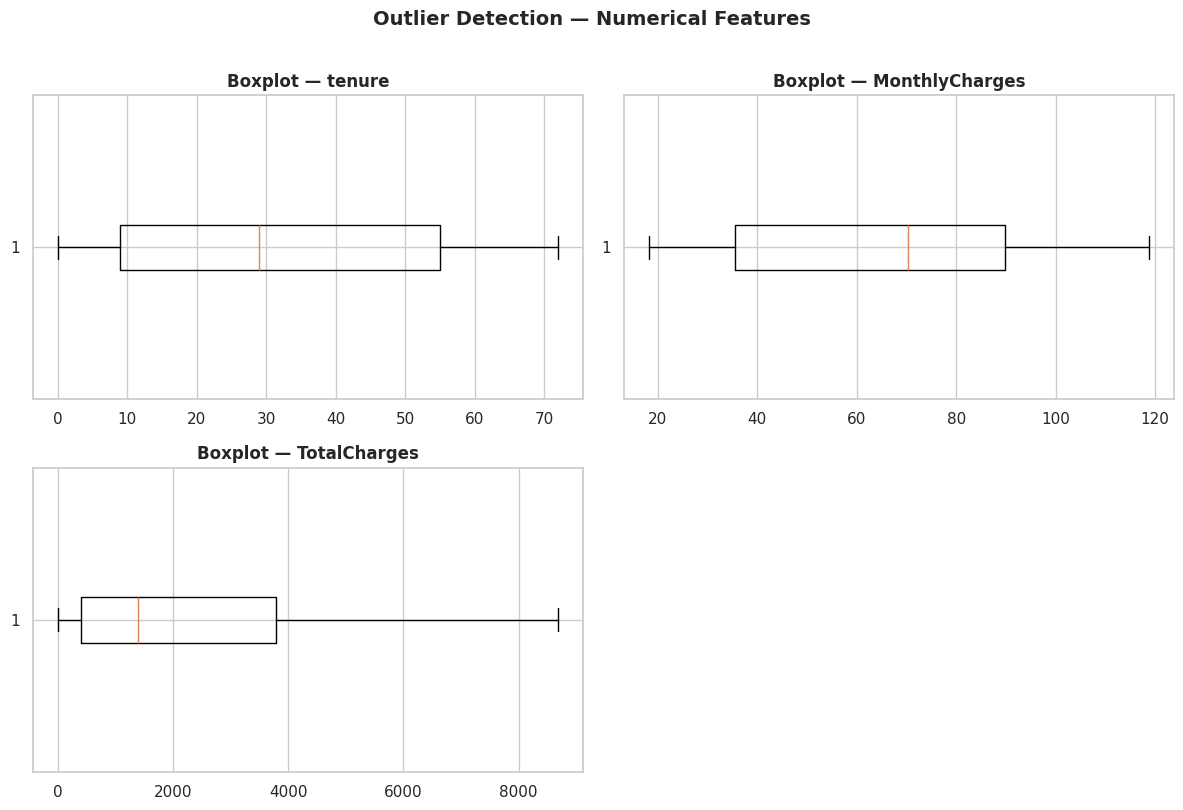

,Feature,Outlier Count,Lower Bound,Upper Bound
0,tenure,0,-60.00,124.00
1,MonthlyCharges,0,-46.02,171.38
2,TotalCharges,0,-4683.52,8868.67


In [37]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Visualise distributions using horizontal boxplots
n_rows = math.ceil(len(numeric_cols) / 2)
plt.figure(figsize=(12, 4 * n_rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, 2, i)
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f'Boxplot — {col}', fontsize=12, fontweight='bold')

plt.suptitle('Outlier Detection — Numerical Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Identify and summarise outliers using the IQR method
outlier_summary = []
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary.append({
        'Feature':        col,
        'Outlier Count':  len(outliers),
        'Lower Bound':    round(lower, 2),
        'Upper Bound':    round(upper, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df)

---
# Section 2 — Impact of Categorical Variables on Churn

> In this section, all categorical variables are automatically detected and their relationship with customer churn is visualised using a dynamically generated grid layout.

Detected 16 categorical features for visualisation.


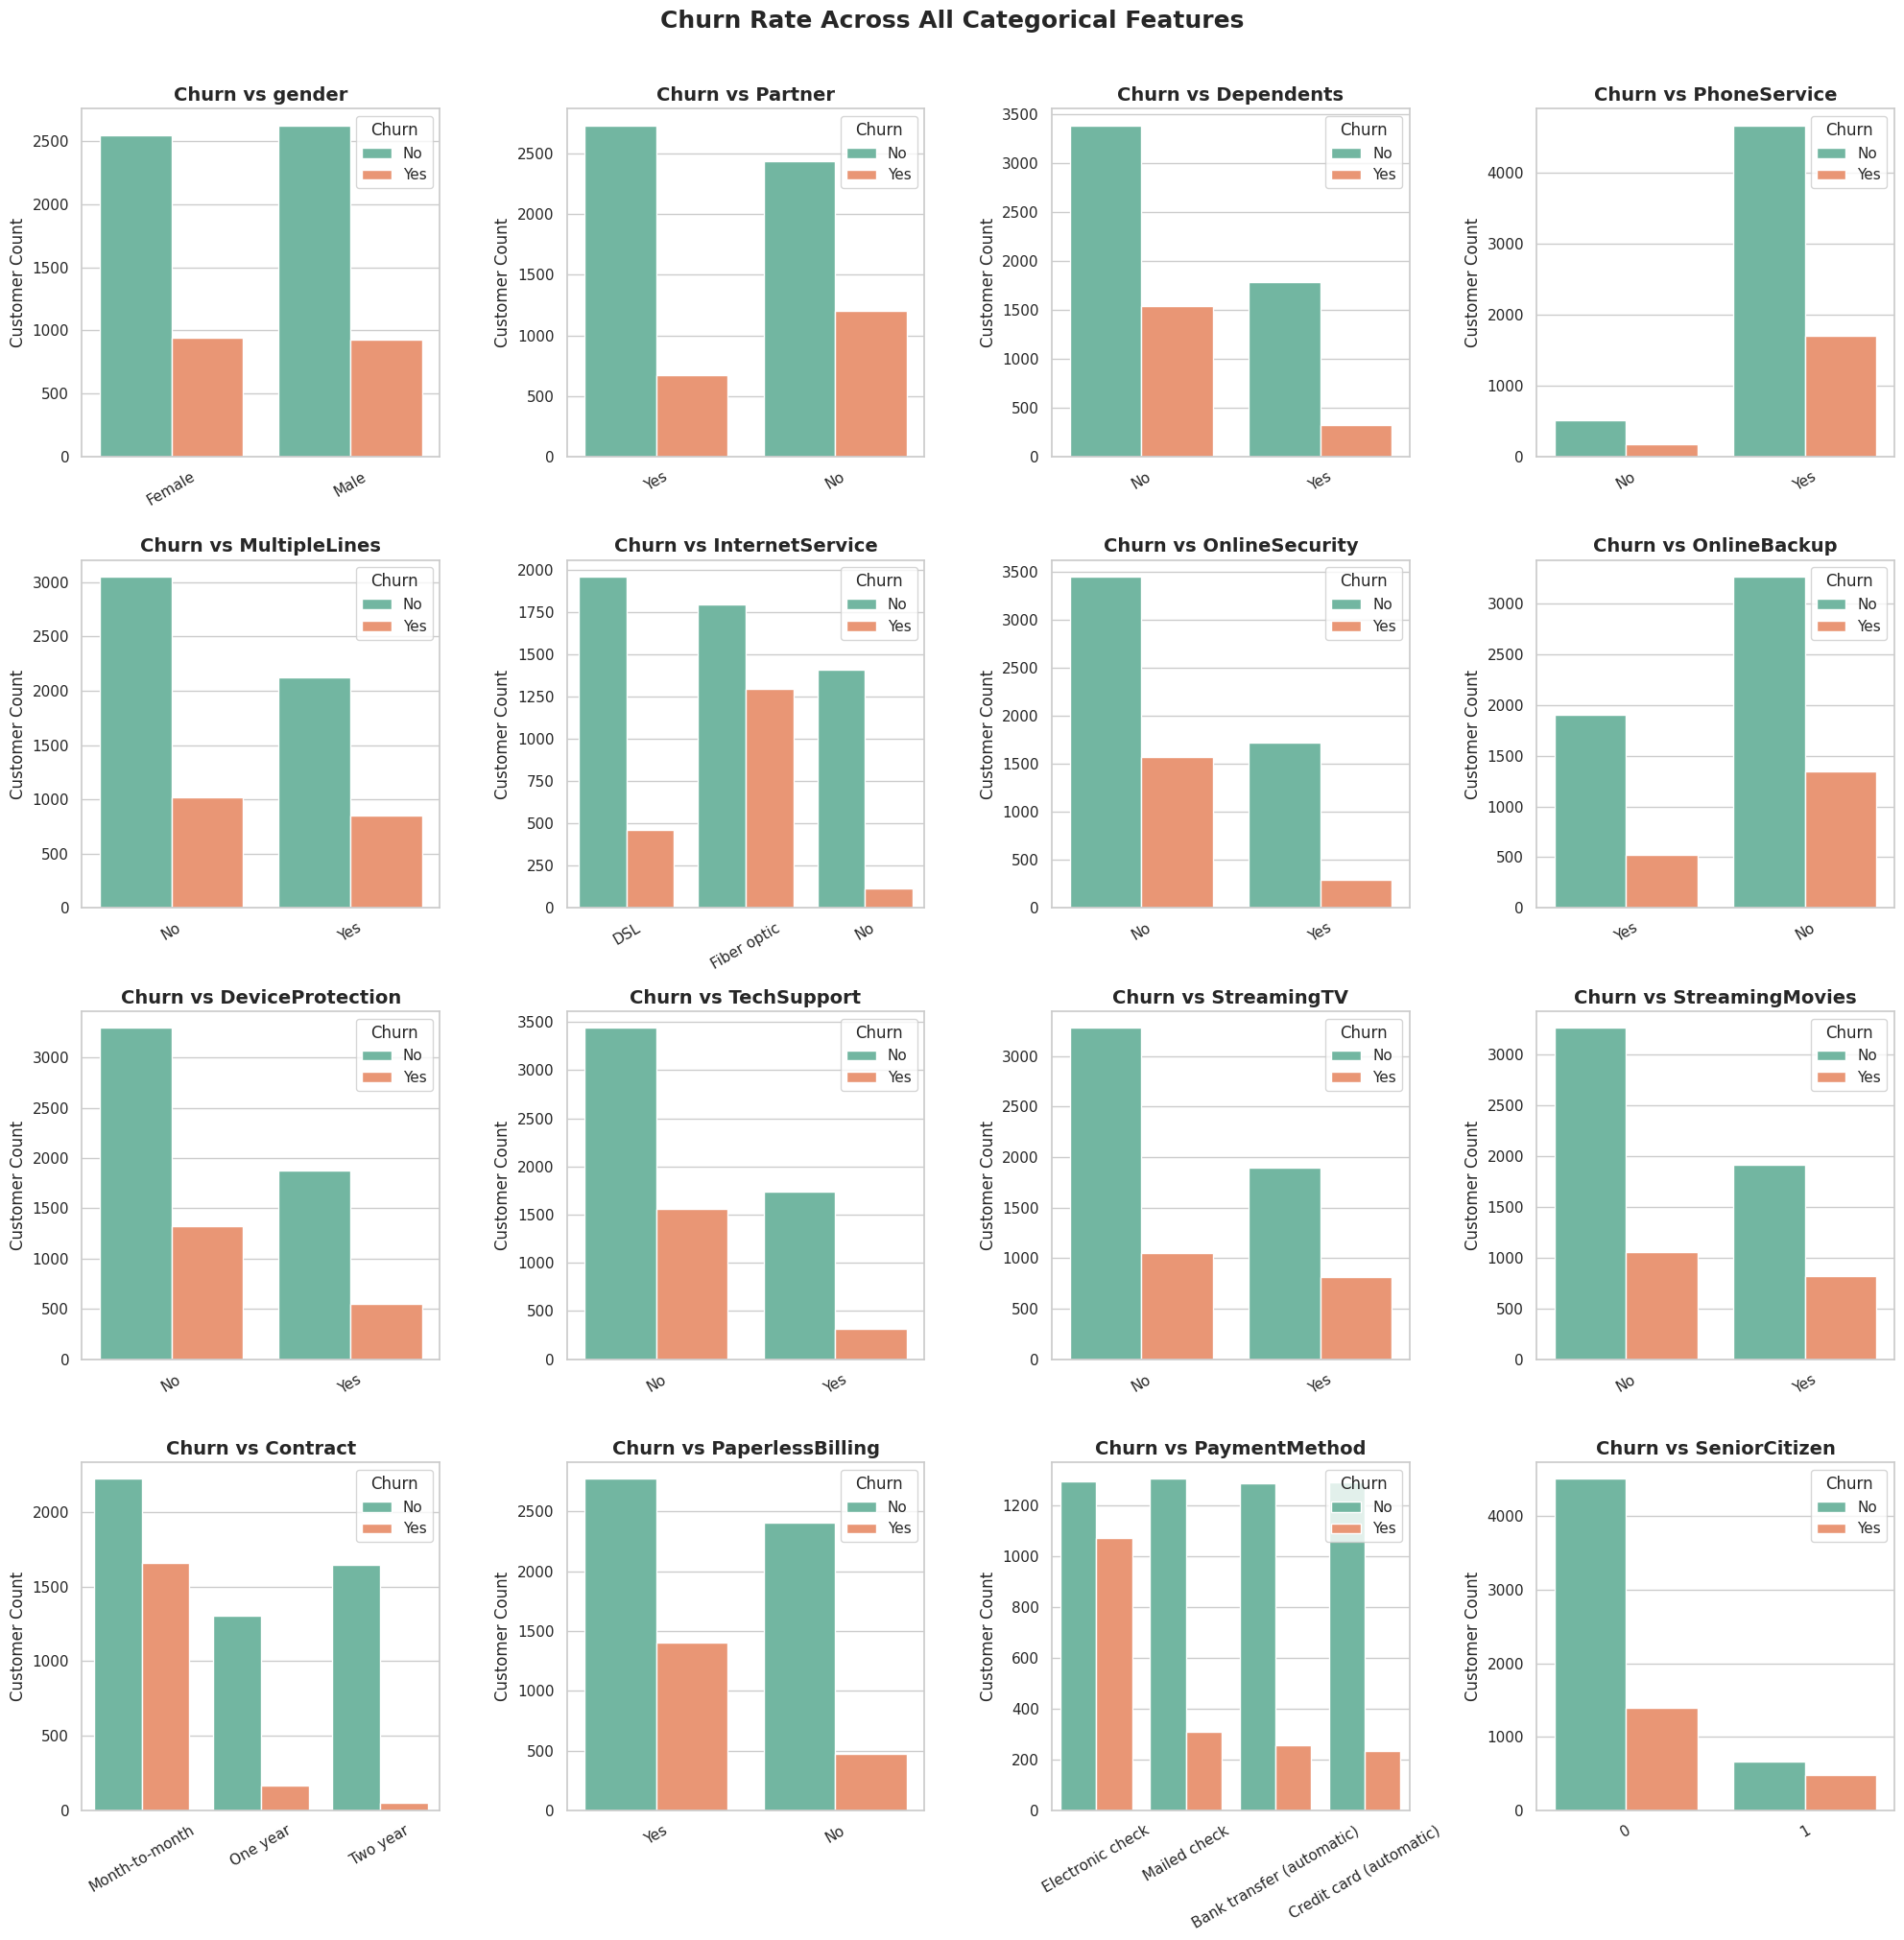

In [38]:
# Automatically detect categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Remove ID and target columns
cols_to_remove = ['customerID', 'Churn']
categorical_cols = [col for col in categorical_cols if col not in cols_to_remove]

# Explicitly include SeniorCitizen (stored as int but represents a category)
if 'SeniorCitizen' in df.columns and 'SeniorCitizen' not in categorical_cols:
    categorical_cols.append('SeniorCitizen')

print(f'Detected {len(categorical_cols)} categorical features for visualisation.')

# Dynamically calculate grid dimensions
ncols = 4
nrows = math.ceil(len(categorical_cols) / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 5 * nrows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, hue='Churn', ax=axes[i], palette='Set2')
    axes[i].set_title(f'Churn vs {col}', fontsize=14, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Customer Count')

# Hide empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Churn Rate Across All Categorical Features',
             fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 📌 Key Insights — Categorical Features at a Glance

> - **Contract type** is the single strongest categorical predictor — month-to-month customers churn at a dramatically higher rate.
> - **Fiber Optic** internet service users churn significantly more than DSL or no-internet customers.
> - **Electronic check** payment users show notably higher churn compared to automated payment methods.
> - Customers **without Tech Support, Online Security, or Online Backup** churn at higher rates — these add-on services act as retention anchors.
> - **Gender, Phone Service, and Multiple Lines** show little to no visible difference in churn rate across categories.

---
# Section 3 — EDA Insights & Strategic Action Plan

> Business insights derived from the dataset, ranked by priority and potential impact on churn reduction.

## 🔴 HIGH PRIORITY — Critical & Immediate Actions

| # | Feature | Relationship to Churn | Recommended Action |
|---|---------|----------------------|--------------------|
| 1 | **Contract Type** | Very strong — month-to-month customers churn at maximum rate | Incentivise month-to-month customers to upgrade to annual contracts via discounts or bundled perks. A shift to long-term contracts has the single largest measurable impact on churn. |
| 2 | **Internet Service** | Very strong — Fiber Optic users are leaving rapidly | Urgently audit Fiber Optic pricing and infrastructure quality. High expectations from Fiber users may be unmet by current service levels. |
| 3 | **Payment Method** | Strong — electronic check / manual payment users are high-risk | Run targeted campaigns to migrate manual-payment customers to automatic payment methods (bank transfer, credit card). |
| 4 | **Tech Support** | Strong — customers without support leave at the first friction point | Proactively offer Tech Support to new customers, high-billing accounts, and recently flagged at-risk profiles. |

## 🟡 MEDIUM PRIORITY — Loyalty & Bundle Strategies

| # | Feature | Relationship to Churn | Recommended Action |
|---|---------|----------------------|--------------------|
| 5 | **Online Security** | Noticeable — unprotected users churn more | Bundle Online Security as a default add-on to directly reduce churn in this segment. |
| 6 | **Online Backup** | Noticeable — users without backup churn more | Include Online Backup in standard packages; data loss anxiety is a retention lever. |
| 7 | **Device Protection** | Noticeable — users without protection churn more | Hardware warranty creates confidence and emotional attachment to the service — promote actively. |
| 8 | **Dependents & Partner** | Moderate — singles and childless customers are the highest-risk group | Introduce "Family & Partner Bundle" incentives to tie solo customers into shared plans. |
| 9 | **Senior Citizen** | Moderate — seniors carry a disproportionately higher churn rate | Design dedicated senior plans with simplified billing, preferential pricing, and specialised support channels. |

## 🟢 LOW PRIORITY — Supportive or Negligible Factors

| # | Feature | Relationship to Churn | Recommended Action |
|---|---------|----------------------|--------------------|
| 10 | **Streaming Movies & TV** | Weak | Use as a **promotional gift** bundled with long-term contract upgrades rather than a standalone retention tool. |
| 11 | **Paperless Billing** | Weak — slight association | Launch a **Digital Loyalty Programme** to retain the digitally engaged segment. |
| — | **Gender, Phone Service, Multiple Lines** | None / negligible | No meaningful impact on churn. **Exclude from models** to reduce noise and improve performance. |

---
# Section 4 — Feature Engineering & Encoding

> Categorical variables must be numerically encoded before feeding into Machine Learning models.  
> Three encoding strategies are applied here:
> - **Binary Encoding** — for Yes/No features
> - **Ordinal Encoding** — for Contract type (ordered relationship: month-to-month < one year < two year)
> - **One-Hot Encoding** — for nominal multi-class features (PaymentMethod, InternetService)

In [39]:
# Work on a copy to preserve the original data
df_encoded = df.copy()

# ── 1. Binary Encoding (Yes → 1, No → 0) ─────────────────────────────────────
binary_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn'
]

for col in binary_cols:
    if col in df_encoded.columns:
        if col == 'gender':
            df_encoded[col] = df_encoded[col].map({'Female': 1, 'Male': 0})
        else:
            df_encoded[col] = df_encoded[col].map({'Yes': 1, 'No': 0})

# ── 2. Ordinal Encoding for Contract Type ─────────────────────────────────────
if 'Contract' in df_encoded.columns:
    df_encoded['Contract'] = df_encoded['Contract'].map({
        'Month-to-month': 0,
        'One year':       1,
        'Two year':       2
    })

# ── 3. One-Hot Encoding for Nominal Multi-Class Variables ─────────────────────
cols_to_encode = ['PaymentMethod', 'InternetService']
existing_cols  = [c for c in cols_to_encode if c in df_encoded.columns]
df_encoded     = pd.get_dummies(data=df_encoded, columns=existing_cols, drop_first=True)

print('Encoding complete. New shape:', df_encoded.shape)
display(df_encoded.head())

Encoding complete. New shape: (7043, 23)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No
0,1,0,1,0,1,0,0,0,1,0,...,0,1,29.85,29.85,0,False,True,False,False,False
1,0,0,0,0,34,1,0,1,0,1,...,1,0,56.95,1889.50,0,False,False,True,False,False
2,0,0,0,0,2,1,0,1,1,0,...,0,1,53.85,108.15,1,False,False,True,False,False
3,0,0,0,0,45,0,0,1,0,1,...,1,0,42.30,1840.75,0,False,False,False,False,False
4,1,0,0,0,2,1,0,0,0,0,...,0,1,70.70,151.65,1,False,True,False,True,False


## 4.1 — Correlation Analysis: Feature Impact on Churn

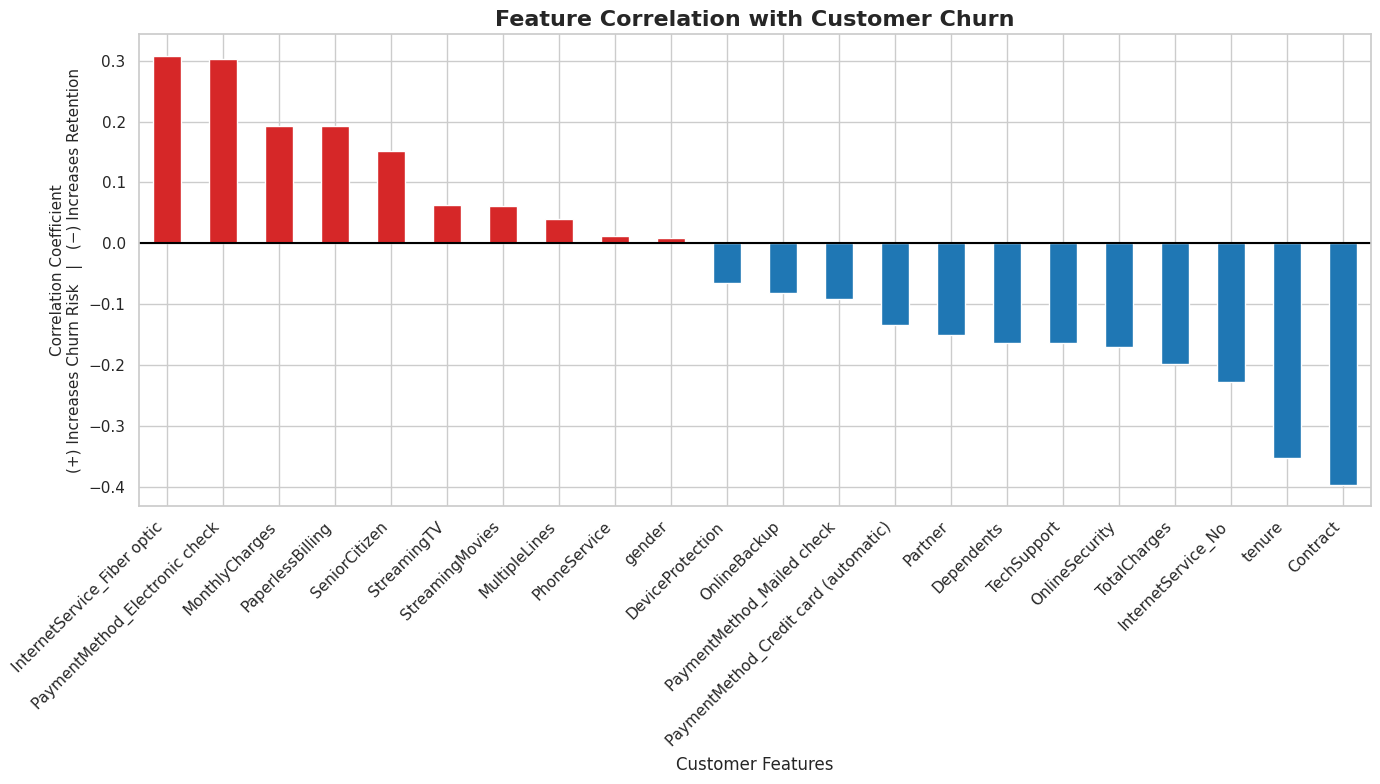

In [40]:
# Calculate correlation of all features with the target (Churn)
churn_corr = df_encoded.corr()['Churn'].drop('Churn').sort_values(ascending=False)

# Color: Red = positive correlation (increases churn risk)
#        Blue = negative correlation (increases retention)
bar_colors = ['#d62728' if x > 0 else '#1f77b4' for x in churn_corr]

plt.figure(figsize=(14, 8))
churn_corr.plot(kind='bar', color=bar_colors)

plt.title('Feature Correlation with Customer Churn', fontsize=16, fontweight='bold')
plt.ylabel('Correlation Coefficient\n(+) Increases Churn Risk   |   (−) Increases Retention', fontsize=11)
plt.xlabel('Customer Features', fontsize=12)
plt.axhline(0, color='black', linewidth=1.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
# Section 5 — Correlation Analysis: Golden Insights

> The correlation bar chart mathematically confirms and ranks the features our Machine Learning model will rely on most heavily.

## 🔴 Biggest Churn Drivers (Positive Correlation — Red Zone)

> These features **increase** the probability of churn. The model will treat them as strong **"flight signals"**.

| Rank | Feature | Interpretation |
|------|---------|----------------|
| 1 | **InternetService — Fiber Optic** | Fiber users are the most likely to churn. Possible cause: pricing vs. perceived value gap or infrastructure dissatisfaction. |
| 2 | **PaymentMethod — Electronic Check** | Manual/electronic-check payers are significantly higher-risk. Likely correlated with lower commitment levels. |
| 3 | **MonthlyCharges** | Higher monthly bills directly correlate with higher churn. Price sensitivity is real. |
| 4 | **PaperlessBilling** | Digitally engaged users who receive paperless bills still churn — they are informed and comparison-shop more actively. |

## 🔵 Strongest Retention Anchors (Negative Correlation — Blue Zone)

> These features **decrease** the probability of churn. The model will treat them as strong **"loyalty signals"**.

| Rank | Feature | Interpretation |
|------|---------|----------------|
| 1 | **Contract Type** | Long-term contracts (1-year, 2-year) are the most powerful retention mechanism. Customers are locked in both contractually and psychologically. |
| 2 | **Tenure** | The longer a customer has been with the company, the less likely they are to leave. Long-tenured customers have sunk cost and habit on their side. |
| 3 | **TechSupport** | Access to technical support dramatically reduces early churn. Customers who feel supported are far less likely to leave after the first issue. |
| 4 | **OnlineSecurity & OnlineBackup** | Customers who subscribe to add-on services have higher perceived value from the bundle, making them stickier. |

## ⚪ Noise Variables (Near-Zero Correlation)

> These features have **no meaningful linear relationship** with churn. Including them in a model adds noise without predictive value.

| Feature | Recommendation |
|---------|----------------|
| **Gender** | Drop from model — no churn signal detected. |
| **PhoneService** | Drop from model — near-uniform distribution across churn groups. |
| **MultipleLines** | Drop from model — marginal effect, not worth the added complexity. |